In [ ]:
# entire https://zenodo.org/records/21485934


In [12]:
#------------------------------------------------------------------------------
#Here's the validation block on its own. It includes everything necessary from main the script up through the min_modulus definition (it needs chi_poly, required_prec, min_modulus, and the exact-data block that builds deformed_h_list):

#------------------------------------------------------------------------------------------------------
# ===== Min-moduli precision validation (c = 1), standalone =====
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      nth_prime, binomial, factorial)

x    = polygen(QQ)
NMAX = 500          # must cover the largest n in `sample` below
c    = 1 #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
ACCURACY_BITS = 60
GUARD_BITS    = 32

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10,10))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---- the validation ----
def validate(sample=(150, 300, 500), extra=256):
    print("  n    prec    min modulus            rel. drift   verdict")
    for n in sample:
        chi  = chi_poly(n)
        prec = max(n,100)+100
        mu   = min_modulus(chi, prec)
        mu2  = min_modulus(chi, prec + extra)
        rel  = abs(mu - mu2)/mu2 if mu2 != 0 else abs(mu - mu2)
        verdict = "OK" if rel < 1e-12 else "RAISE ACCURACY_BITS"
        print("%3d  %6d  %-22.14f  %.2e   %s"
              % (n, prec, mu, float(rel), verdict))

validate()

  n    prec    min modulus            rel. drift   verdict
150     250  320.61432065089207      2.08e-44   OK
300     400  647.80779739522541      1.91e-53   OK
500     600  1084.34707422032852     7.05e-66   OK


In [2]:
#------------------------------------------------------------------------------
#Here's the validation block on its own. It includes everything necessary from main the script up through the min_modulus definition (it needs chi_poly, required_prec, min_modulus, and the exact-data block that builds deformed_h_list):

#------------------------------------------------------------------------------------------------------
# ===== Min-moduli precision validation (c = 1), standalone =====
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      nth_prime, binomial, factorial)

x    = polygen(QQ)
NMAX = 500          # must cover the largest n in `sample` below
c    = 1 #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
ACCURACY_BITS = 60
GUARD_BITS    = 32

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10**3,10**3))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---- the validation ----
def validate(sample=(150, 300, 500), extra=256):
    print("  n    prec    min modulus            rel. drift   verdict")
    for n in sample:
        chi  = chi_poly(n)
        prec = max(n,100)+100
        mu   = min_modulus(chi, prec)
        mu2  = min_modulus(chi, prec + extra)
        rel  = abs(mu - mu2)/mu2 if mu2 != 0 else abs(mu - mu2)
        verdict = "OK" if rel < 1e-12 else "RAISE ACCURACY_BITS"
        print("%3d  %6d  %-22.14f  %.2e   %s"
              % (n, prec, mu, float(rel), verdict))

validate()

  n    prec    min modulus            rel. drift   verdict
150     250  42.95215975607776       8.24e-76   OK
300     400  18.92384401403170       0.00e+00   OK
500     600  16.54266876865231       0.00e+00   OK


In [4]:
#------------------------------------------------------------------------------
#Here's the validation block on its own. It includes everything necessary from main the script up through the min_modulus definition (it needs chi_poly, required_prec, min_modulus, and the exact-data block that builds deformed_h_list):

#------------------------------------------------------------------------------------------------------
# ===== Min-moduli precision validation (c = 1), standalone =====
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      nth_prime, binomial, factorial)

x    = polygen(QQ)
NMAX = 500          # must cover the largest n in `sample` below
c    = 1 #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
ACCURACY_BITS = 60
GUARD_BITS    = 32

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10**6,10**6))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---- the validation ----
def validate(sample=(150, 300, 500), extra=256):
    print("  n    prec    min modulus            rel. drift   verdict")
    for n in sample:
        chi  = chi_poly(n)
        prec = max(n,100)+100
        mu   = min_modulus(chi, prec)
        mu2  = min_modulus(chi, prec + extra)
        rel  = abs(mu - mu2)/mu2 if mu2 != 0 else abs(mu - mu2)
        verdict = "OK" if rel < 1e-12 else "RAISE ACCURACY_BITS"
        print("%3d  %6d  %-22.14f  %.2e   %s"
              % (n, prec, mu, float(rel), verdict))

validate()

  n    prec    min modulus            rel. drift   verdict
150     250  22655674.09954039379954  1.27e-46   OK
300     400  47109396.54966910183430  1.95e-55   OK
500     600  79767470.61250309646130  2.78e-67   OK


(1, 200, 2.8363863627115886e-05)
(2, 200, 3.528197606404622e-05)
(3, 200, 4.334847132364909e-05)
(4, 200, 5.458196004231771e-05)
(5, 200, 7.648070653279623e-05)
(6, 200, 9.609858194986979e-05)
(7, 200, 0.00012111266454060873)
(8, 200, 0.00016342798868815105)
(9, 200, 0.000209347407023112)
(10, 200, 0.0002598285675048828)
(11, 200, 0.0003313660621643066)
(12, 200, 0.00040871699651082356)
(13, 200, 0.0005004167556762696)
(14, 200, 0.0005985498428344727)
(15, 200, 0.0007213830947875976)
(16, 200, 0.0008583625157674153)
(17, 200, 0.001015913486480713)
(18, 200, 0.0011876980463663737)
(19, 200, 0.00137023131052653)
(20, 200, 0.0015676140785217286)
(21, 200, 0.0017862995465596518)
(22, 200, 0.002022679646809896)
(23, 200, 0.00226666529973348)
(24, 200, 0.0025529821713765463)
(25, 200, 0.002854899565378825)
(26, 200, 0.003179045518239339)
(27, 200, 0.0035371820131937662)
(28, 200, 0.003930413722991943)
(29, 200, 0.004379697640736898)
(30, 200, 0.004834465185801188)
(31, 200, 0.005298213164011

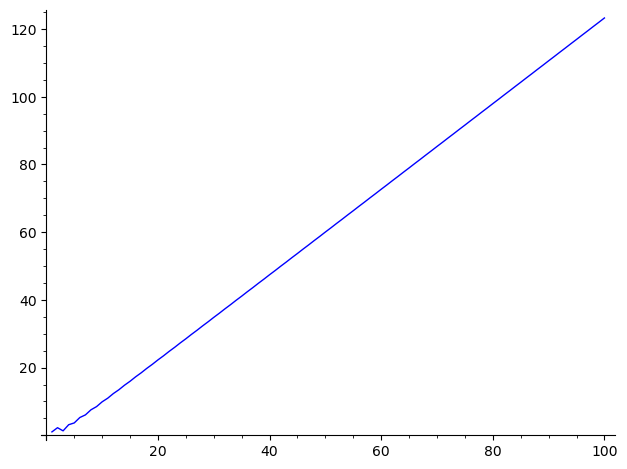

In [13]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10,10))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 101):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 2.9218196868896484e-05)
(2, 200, 3.473361333211263e-05)
(3, 200, 4.363457361857097e-05)
(4, 200, 5.660057067871094e-05)
(5, 200, 7.153352101643881e-05)
(6, 200, 9.621779123942057e-05)
(7, 200, 0.00012893279393513997)
(8, 200, 0.00017283360163370767)
(9, 200, 0.0002203504244486491)
(10, 200, 0.0002768993377685547)
(11, 200, 0.00034123659133911133)
(12, 200, 0.00042208433151245115)
(13, 200, 0.0005263328552246094)
(14, 200, 0.0006332159042358399)
(15, 200, 0.0007507999738057455)
(16, 200, 0.0008928855260213216)
(17, 200, 0.0010582168896993002)
(18, 200, 0.0012405832608540853)
(19, 200, 0.0014493465423583984)
(20, 200, 0.0016458670298258463)
(21, 200, 0.0018739660580952963)
(22, 200, 0.0021294514338175458)
(23, 200, 0.002401153246561686)
(24, 200, 0.0027096827824910482)
(25, 200, 0.0030334830284118653)
(26, 200, 0.0033843318621317544)
(27, 200, 0.00377348264058431)
(28, 200, 0.004175782203674316)
(29, 200, 0.004617416858673095)
(30, 200, 0.00508649746576945)
(31, 200, 0.005580178

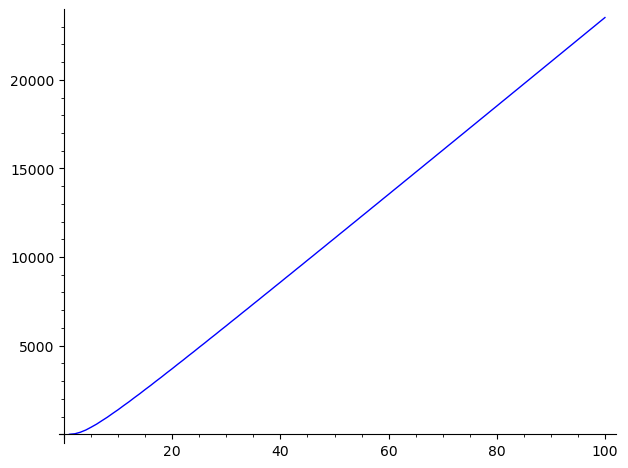

In [7]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,501):
    expansion.append(randint(-10**3,10**3))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 101):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 3.453493118286133e-05)
(2, 200, 4.005034764607747e-05)
(3, 200, 4.829963048299154e-05)
(4, 200, 6.131728490193685e-05)
(5, 200, 7.656415303548177e-05)
(6, 200, 0.00010195175806681315)
(7, 200, 0.00013500054677327474)
(8, 200, 0.00017869869867960612)
(9, 200, 0.0002266844113667806)
(10, 200, 0.00028028090794881183)
(11, 200, 0.00034659703572591146)
(12, 200, 0.0004271825154622396)
(13, 200, 0.0005263487497965494)
(14, 200, 0.0006309310595194499)
(15, 200, 0.0007562994956970215)
(16, 200, 0.0009039998054504395)
(17, 200, 0.0010642687479654948)
(18, 200, 0.0012450655301411947)
(19, 200, 0.0014468987782796225)
(20, 200, 0.001653448740641276)
(21, 200, 0.0018880327542622885)
(22, 200, 0.0021402478218078614)
(23, 200, 0.002421847979227702)
(24, 200, 0.002745834986368815)
(25, 200, 0.0030874133110046385)
(26, 200, 0.0034623146057128906)
(27, 200, 0.0038646658261617026)
(28, 200, 0.004302863279978434)
(29, 200, 0.004770247141520182)
(30, 200, 0.005271613597869873)
(31, 200, 0.00580619

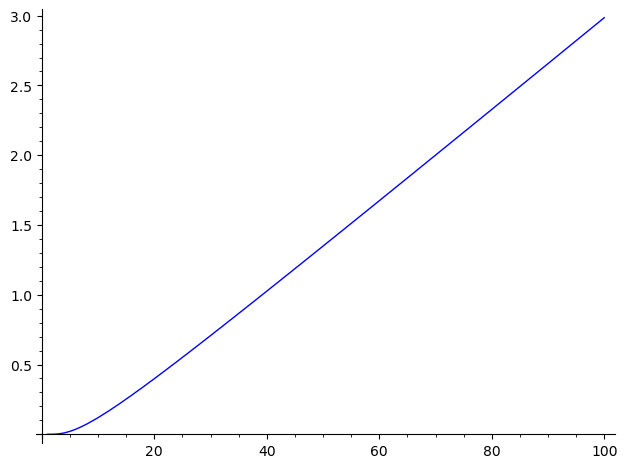

In [8]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10**6,10**6))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 101):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 3.931522369384766e-05)
(2, 200, 4.638036092122396e-05)
(3, 200, 5.515019098917643e-05)
(4, 200, 6.7444642384847e-05)
(5, 200, 8.446772893269857e-05)
(6, 200, 0.00014509757359822592)
(7, 200, 0.00019626617431640626)
(8, 200, 0.00024341742197672527)
(9, 200, 0.00029851595560709634)
(10, 200, 0.0003648161888122559)
(11, 200, 0.00045489867528279623)
(12, 200, 0.0005219300587972005)
(13, 200, 0.0005949815114339193)
(14, 200, 0.0008214990297953288)
(15, 200, 0.001040645440419515)
(16, 200, 0.0012410322825113932)
(17, 200, 0.0015200336774190268)
(18, 200, 0.0018160621325174968)
(19, 200, 0.0021572311719258628)
(20, 200, 0.0025443474451700846)
(21, 200, 0.0030112981796264647)
(22, 200, 0.003343598047892253)
(23, 200, 0.0036487976710001626)
(24, 200, 0.003939497470855713)
(25, 200, 0.0042495290438334145)
(26, 200, 0.004769933223724365)
(27, 200, 0.005304813385009766)
(28, 200, 0.005902564525604248)
(29, 200, 0.006504849592844645)
(30, 200, 0.007054181893666586)
(31, 200, 0.007676164309

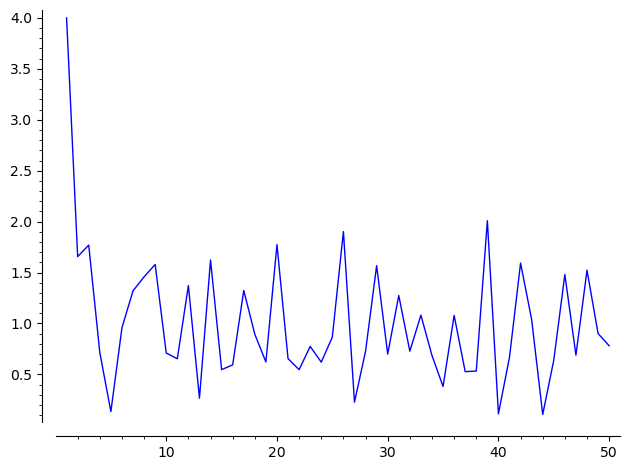

In [11]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10,10))

h_list=[1]+expansion # h_0 = 1 required by the lemmas

def h(n): return h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 51):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 4.616578420003255e-05)
(2, 200, 5.487998326619466e-05)
(3, 200, 6.424983342488607e-05)
(4, 200, 7.57137934366862e-05)
(5, 200, 0.00010033448537190755)
(6, 200, 0.00011968215306599935)
(7, 200, 0.00014530022939046223)
(8, 200, 0.00018781820933024088)
(9, 200, 0.00026404857635498047)
(10, 200, 0.00033578077952067055)
(11, 200, 0.0004070480664571126)
(12, 200, 0.0004946509997049968)
(13, 200, 0.0006601850191752116)
(14, 200, 0.0008167862892150879)
(15, 200, 0.0009789665540059407)
(16, 200, 0.0010987162590026856)
(17, 200, 0.0012693325678507486)
(18, 200, 0.0014485994974772136)
(19, 200, 0.0016719818115234375)
(20, 200, 0.0018923362096150717)
(21, 200, 0.0021178325017293296)
(22, 200, 0.0023942351341247558)
(23, 200, 0.0026791175206502277)
(24, 200, 0.002966030438741048)
(25, 200, 0.0036060134569803875)
(26, 200, 0.003992899258931478)
(27, 200, 0.004500949382781982)
(28, 200, 0.004942448933919271)
(29, 200, 0.005897748470306397)
(30, 200, 0.006337030728658041)
(31, 200, 0.00715141

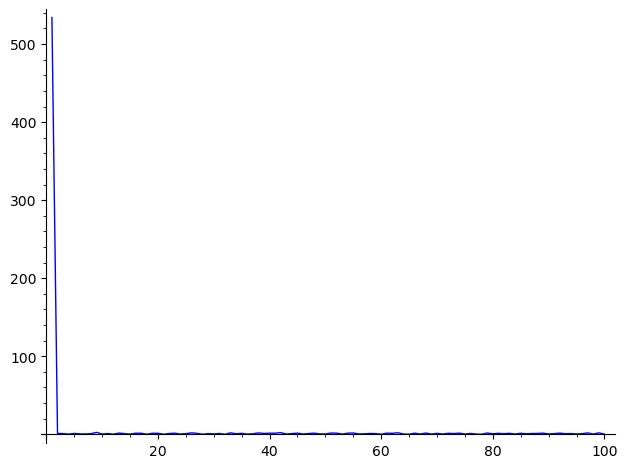

In [9]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10**3,10**3))

h_list=[1]+expansion # h_0 = 1 required by the lemmas

def h(n): return h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 101):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 4.836718241373698e-05)
(2, 200, 5.79833984375e-05)
(3, 200, 6.686846415201822e-05)
(4, 200, 7.725159327189127e-05)
(5, 200, 0.00011659860610961914)
(6, 200, 0.00014038483301798504)
(7, 200, 0.0001769701639811198)
(8, 200, 0.00021703243255615233)
(9, 200, 0.00026148160298665365)
(10, 200, 0.0003115336100260417)
(11, 200, 0.000371853510538737)
(12, 200, 0.00045183499654134117)
(13, 200, 0.0005506356557210286)
(14, 200, 0.0006569345792134603)
(15, 200, 0.0007966319719950358)
(16, 200, 0.0009495496749877929)
(17, 200, 0.001107951005299886)
(18, 200, 0.0012439529101053873)
(19, 200, 0.0014552672704060872)
(20, 200, 0.001806652545928955)
(21, 200, 0.0021268526713053384)
(22, 200, 0.0024618665377298993)
(23, 200, 0.0027481873830159506)
(24, 200, 0.003101464112599691)
(25, 200, 0.003420666853586833)
(26, 200, 0.004203017552693685)
(27, 200, 0.004853403568267823)
(28, 200, 0.005406399567921956)
(29, 200, 0.00607601801554362)
(30, 200, 0.006752653916676839)
(31, 200, 0.00737291971842447

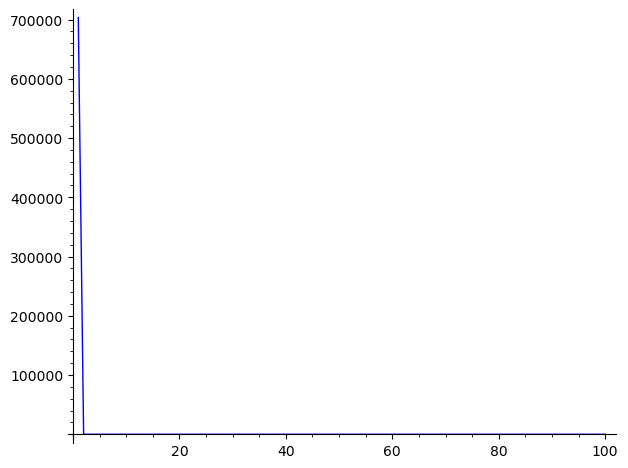

In [10]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10**6,10**6))

h_list=[1]+expansion # h_0 = 1 required by the lemmas

def h(n): return h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 101):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 4.87526257832845e-05)
(2, 200, 5.526542663574219e-05)
(3, 200, 6.418228149414062e-05)
(4, 200, 7.44024912516276e-05)
(5, 200, 0.00011183420817057292)
(6, 200, 0.0001336812973022461)
(7, 200, 0.00016222000122070312)
(8, 200, 0.00018995205561319988)
(9, 200, 0.00023688475290934246)
(10, 200, 0.00032213528951009117)
(11, 200, 0.00040818452835083007)
(12, 200, 0.0005576014518737793)
(13, 200, 0.0007606466611226399)
(14, 200, 0.0009063839912414551)
(15, 200, 0.0010645826657613119)
(16, 200, 0.0012401024500528972)
(17, 200, 0.0013707677523295085)
(18, 200, 0.0017125169436136881)
(19, 200, 0.0020059982935587565)
(20, 200, 0.0022586822509765626)
(21, 200, 0.0024390339851379393)
(22, 200, 0.002918799718221029)
(23, 200, 0.003406818707784017)
(24, 200, 0.0038855671882629395)
(25, 200, 0.004404600461324056)
(26, 200, 0.005122780799865723)
(27, 200, 0.00568010409673055)
(28, 200, 0.006187470753987631)
(29, 200, 0.006685018539428711)
(30, 200, 0.007153550783793132)
(31, 200, 0.007483017444

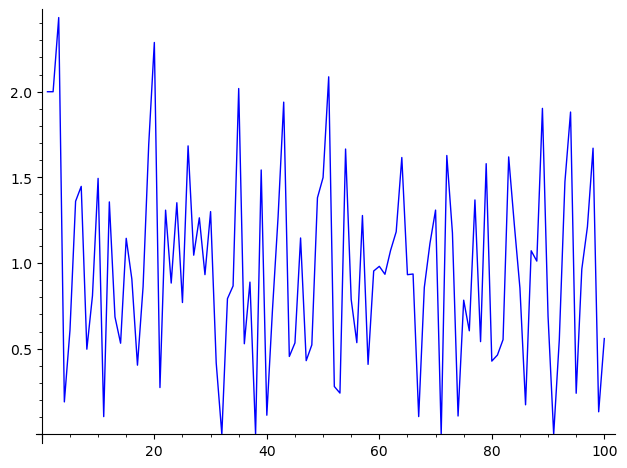

In [15]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,500):
    expansion.append(randint(-10,10))

h_list=[1]+expansion # h_0 = 1 required by the lemmas

def h(n): return h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 101):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

(1, 200, 0.0012390971183776855)
(2, 200, 0.001638336976369222)
(3, 200, 0.0017106850941975911)
(4, 200, 0.0017636020978291829)
(5, 200, 0.0017870148022969565)
(6, 200, 0.0018076499303181965)
(7, 200, 0.0018440683682759602)
(8, 200, 0.0018868525822957358)
(9, 200, 0.0019367496172587077)
(10, 200, 0.001991454760233561)
(11, 200, 0.0020602822303771974)
(12, 200, 0.0021349827448527018)
(13, 200, 0.0022390166918436686)
(14, 200, 0.002368183930714925)
(15, 200, 0.002498165766398112)
(16, 200, 0.0026536822319030763)
(17, 200, 0.002820165952046712)
(18, 200, 0.0030036330223083495)
(19, 200, 0.003190767765045166)
(20, 200, 0.0034035841623942056)
(21, 200, 0.0036302049954732257)
(22, 200, 0.0038734833399454755)
(23, 200, 0.004133184750874837)
(24, 200, 0.004427198568979899)
(25, 200, 0.004763686656951904)
(26, 200, 0.0051285187403361)
(27, 200, 0.0054909706115722655)
(28, 200, 0.0059189995129903155)
(29, 200, 0.0063569029172261555)
(30, 200, 0.006829837958017985)
(31, 200, 0.007346900304158529)


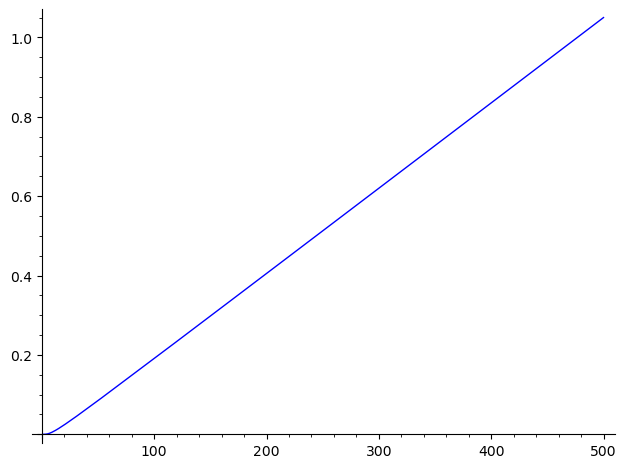

In [4]:
import pickle
from sage.all import sigma, nth_prime
import ast


# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
import pickle, os
from sage.all import (QQ, polygen, ComplexField,
                      binomial, factorial, list_plot)
x    = polygen(QQ)
def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast


expansion=[]
for n in range(1,501):
    expansion.append(randint(-10**6,10**6))

h_list=[1]+expansion # h_0 = 1 required by the lemmas
# ---- exact data (no precision loss here) ----
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(1)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))


# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > 501, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(bound={bound}, coeffs={len(coeffs_list)}, c={c})"
)


# ---------- MAIN RUN ----------
start = time.time()
mins_list = []
chi_list=[]
roots_list=[]
for n in range(1, 501):
    chi  = chi_poly(n)            # build once
    chi_list.append((n,chi))
    prec = max(n,100)+100    # reuse chi
    CCp  = ComplexField(prec)     # adaptive precision, not the global 53-bit CC
    roots=chi.roots(ring=CCp, multiplicities=False)
    roots_list.append((n,roots))
    mu   = min(r.abs() for r in roots)   # mu from the same roots; no second solve
    mins_list.append((n, float(mu)))
    print((n,prec,(time.time() - start)/60))
    

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()

with open('/Users/barrybrent/data2/run21jul26no1.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) #
with open('/Users/barrybrent/data2/run21jul26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile) #
with open('/Users/barrybrent/data2/run21jul26no3.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
    # 
with open('/Users/barrybrent/data2/run21jul26no4.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) # 
with open('/Users/barrybrent/data2/run21jul26no5.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) 

Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 1.000000 to 104988931.813134

SEGMENTATION  (for context; only the LAST segment is analyzed)
  Breakpoints detected (after merge): 0
  Segment 1: n = 1 to 500  (500 points)  range [1.00, 104988931.81]  <-- ANALYZED

FINAL SEGMENT METRICS  (n = 1 to 500, 500 points)

  [Detrending]
    linear-fit slope        : 214017.408401
    residual std dev        : 214613.925223
    residual / value scale  : 2.044e-03

  [Envelope]
    dynamic range (p90/p10) : 6.128
    monotonicity (|Spearman|): 0.397
    normalization applied   : False

  [Spectral baseline]
    AR(1) lag-1 autocorr rho: 0.9989
    frequency bins tested   : 247
    max credible period     : 166.7  (= n/3)

  [FFT peaks (period <= n/3), strongest first]
    (no FFT peaks with period <= n/3)

  [Multi-scale ACF]
    white-noise 95% band    : +/- 0.0877  (ACF values within this band are consistent with noise)
    (no ACF peaks above 0.1 at any scale)


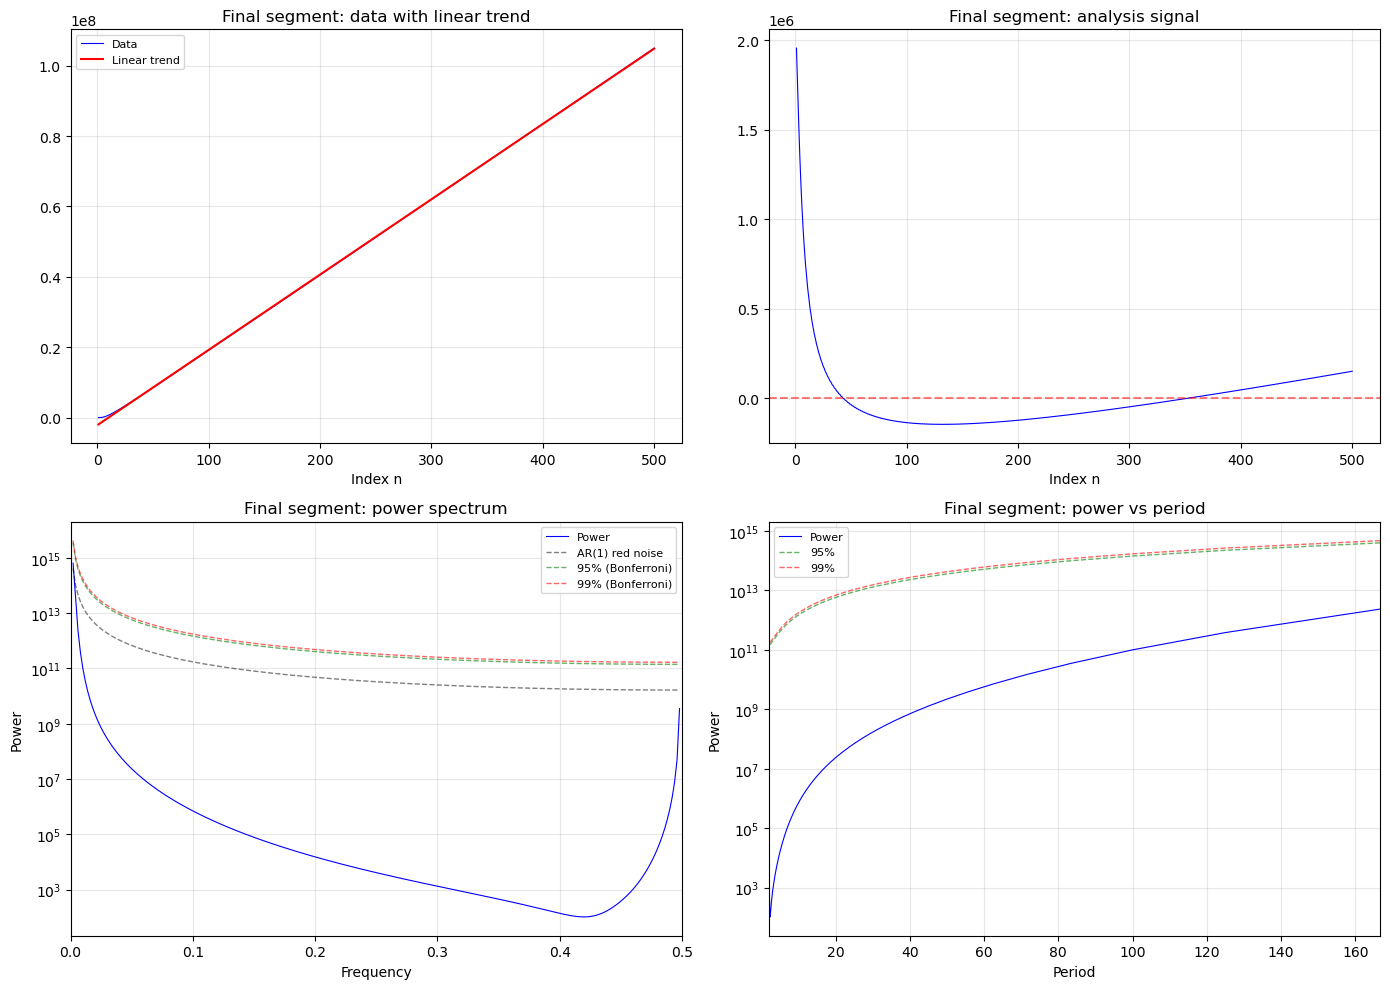


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run21jul26no4.txt','rb') as rfile:
    mins_list = pickle.load(rfile)
# SEGMENTED FOURIER ANALYSIS OF MINIMUM MODULI  (v11)
#
# DESIGN CHANGES RELATIVE TO v10:
#
#  1. LAST SEGMENT ONLY.  The oscillation phenomenon emerges as the index n
#     grows, so only the final segment (after the last structural breakpoint)
#     is analyzed.  Earlier segments are located, reported, and plotted for
#     context only ‚Äî they are not analyzed for periodicity.
#
#  2. NO VERDICTS.  The code does not output PERIODIC / NOT PERIODIC labels.
#     It reports the raw metrics and their scores, and leaves interpretation
#     to the reader.  The metrics are:
#       - linear-detrend slope and residual standard deviation
#       - envelope dynamic range and monotonicity (and whether normalization
#         was applied)
#       - AR(1) lag-1 autocorrelation (rho)
#       - FFT peak periods with their power and the Bonferroni-corrected
#         95% / 99% red-noise thresholds at the same frequency
#       - multi-scale ACF: each detected period, the scale at which it was
#         found, and its ACF strength, with the fundamental identified
#       - the white-noise ACF reference band (1.96 / sqrt(n)), so the ACF
#         strengths can be judged against what white noise would produce
#
#  3. VISUALIZATIONS restricted to the final segment.
#
# Segmentation (level-based ruptures Pelt with l2 cost, plus slope-merge
# cleanup) and the analysis machinery are carried over unchanged from v10.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt
import ruptures as rpt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. BREAKPOINT DETECTION  (level-based, with slope-merge cleanup)
# ==============================================================================
# Used only to locate the final segment.  Detection is the ruptures Pelt
# algorithm with the l2 (mean-shift) cost on the data levels, followed by a
# slope-merge step that collapses adjacent segments of nearly equal slope
# (so an over-segmented linear ramp becomes one segment).

penalty_value = np.log(N) * np.var(minmoduli)
algo = rpt.Pelt(model="l2", min_size=max(20, N // 10)).fit(minmoduli)
breakpoints = algo.predict(pen=penalty_value)
seg_boundaries = [0] + breakpoints

_idx = np.arange(N)
_merged = True
while _merged and len(seg_boundaries) > 2:
    _merged = False
    slopes = []
    for i in range(len(seg_boundaries) - 1):
        s, e = seg_boundaries[i], seg_boundaries[i+1]
        slopes.append(np.polyfit(_idx[s:e], minmoduli[s:e], 1)[0])
    slope_scale = max(abs(max(slopes)), abs(min(slopes)), 1e-9)
    for i in range(len(slopes) - 1):
        if abs(slopes[i] - slopes[i+1]) < 0.15 * slope_scale:
            seg_boundaries.pop(i + 1)
            _merged = True
            break

n_segments = len(seg_boundaries) - 1

print(f"\n{'='*75}")
print(f"SEGMENTATION  (for context; only the LAST segment is analyzed)")
print(f"{'='*75}")
print(f"  Breakpoints detected (after merge): {n_segments - 1}")
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    si = indices[start_idx:end_idx]
    sv = minmoduli[start_idx:end_idx]
    tag = "  <-- ANALYZED" if i == n_segments - 1 else ""
    print(f"  Segment {i+1}: n = {int(si[0])} to {int(si[-1])}  "
          f"({end_idx - start_idx} points)  "
          f"range [{sv.min():.2f}, {sv.max():.2f}]{tag}")

# ==============================================================================
# 3. METRICS FOR THE FINAL SEGMENT
# ==============================================================================
last_start = seg_boundaries[-2]
last_end = seg_boundaries[-1]
seg_indices = indices[last_start:last_end]
seg_values = minmoduli[last_start:last_end]
n = len(seg_indices)

print(f"\n{'='*75}")
print(f"FINAL SEGMENT METRICS  (n = {int(seg_indices[0])} to {int(seg_indices[-1])}, "
      f"{n} points)")
print(f"{'='*75}")

metrics = {}  # collected for the visualization section

if n < 10:
    print(f"  Final segment too short ({n} points) for analysis.")
    metrics = None
else:
    max_credible_period = n / 3.0

    # --- Linear detrend ---
    coeffs = np.polyfit(seg_indices, seg_values, deg=1)
    trend = np.polyval(coeffs, seg_indices)
    detrended = seg_values - trend
    slope = coeffs[0]

    print(f"\n  [Detrending]")
    print(f"    linear-fit slope        : {slope:.6f}")
    print(f"    residual std dev        : {np.std(detrended):.6f}")

    value_scale = max(np.max(np.abs(seg_values)), 1e-30)
    resid_ratio = np.std(detrended) / value_scale
    print(f"    residual / value scale  : {resid_ratio:.3e}")

    # --- Envelope normalization ---
    abs_det = np.abs(detrended)
    env_win = max(5, min(n // 10, n // 3))
    if env_win % 2 == 0:
        env_win += 1
    env_win = min(env_win, n - 1)
    if env_win % 2 == 0:
        env_win -= 1
    if env_win < 5:
        env_win = 5

    envelope = None
    if env_win >= n:
        envelope_applied = False
        analysis_signal = detrended
        envelope_ratio = float('nan')
        env_monotonicity = float('nan')
    else:
        envelope = signal.savgol_filter(abs_det, window_length=env_win,
                                        polyorder=min(2, env_win - 1))
        env_floor = np.percentile(abs_det[abs_det > 0], 5) if np.any(abs_det > 0) else 1.0
        envelope = np.maximum(envelope, env_floor)
        env_p10 = np.percentile(envelope, 10)
        env_p90 = np.percentile(envelope, 90)
        envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0
        sp = stats.spearmanr(np.arange(n), envelope).correlation
        env_monotonicity = abs(sp) if sp == sp else 0.0
        if envelope_ratio > 3.0 and env_monotonicity > 0.6:
            analysis_signal = detrended / envelope
            envelope_applied = True
        else:
            analysis_signal = detrended
            envelope_applied = False

    print(f"\n  [Envelope]")
    print(f"    dynamic range (p90/p10) : {envelope_ratio:.3f}")
    print(f"    monotonicity (|Spearman|): {env_monotonicity:.3f}")
    print(f"    normalization applied   : {envelope_applied}")

    # --- Windowed FFT ---
    window = np.hanning(n)
    windowed = analysis_signal * window
    window_power_correction = n / np.sum(window**2)
    fft_result = np.fft.fft(windowed)
    fft_freqs = np.fft.fftfreq(n, d=1.0)
    power_spectrum = np.abs(fft_result)**2 * window_power_correction
    pos = fft_freqs > 0
    frequencies = fft_freqs[pos]
    power = power_spectrum[pos]
    periods = 1.0 / frequencies

    # --- AR(1) red-noise baseline + Bonferroni-corrected thresholds ---
    rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
    variance = np.var(analysis_signal)
    ar1_power = (variance * (1 - rho**2)) / (
        1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
    )
    ar1_power *= np.mean(power) / np.mean(ar1_power)

    credible_mask = periods <= max_credible_period
    n_tests = int(np.sum(credible_mask))
    if n_tests < 1:
        n_tests = 1
    chi2_95 = stats.chi2.ppf(1.0 - (0.05 / n_tests), df=2) / 2.0
    chi2_99 = stats.chi2.ppf(1.0 - (0.01 / n_tests), df=2) / 2.0
    conf_95 = ar1_power * chi2_95
    conf_99 = ar1_power * chi2_99

    print(f"\n  [Spectral baseline]")
    print(f"    AR(1) lag-1 autocorr rho: {rho:.4f}")
    print(f"    frequency bins tested   : {n_tests}")
    print(f"    max credible period     : {max_credible_period:.1f}  (= n/3)")

    # --- FFT peaks: report power against thresholds (no verdict) ---
    peak_idx = signal.find_peaks(power, height=0)[0]
    peak_rows = []
    for pi in peak_idx:
        if not credible_mask[pi]:
            continue
        peak_rows.append((periods[pi], power[pi], conf_95[pi], conf_99[pi],
                          power[pi] / conf_95[pi] if conf_95[pi] > 0 else float('nan')))
    peak_rows.sort(key=lambda r: r[1], reverse=True)

    print(f"\n  [FFT peaks (period <= n/3), strongest first]")
    if peak_rows:
        print(f"    {'Period':>8} {'Power':>12} {'95% thr':>12} {'99% thr':>12} "
              f"{'Power/95%':>10}")
        for per, pw, c95, c99, ratio in peak_rows[:10]:
            print(f"    {per:>8.2f} {pw:>12.3e} {c95:>12.3e} {c99:>12.3e} "
                  f"{ratio:>10.2f}")
    else:
        print(f"    (no FFT peaks with period <= n/3)")

    # --- Multi-scale ACF detection ---
    detected_periods = []
    smooth_widths = [1]
    w = 3
    while w < max_credible_period / 2:
        smooth_widths.append(w)
        w = max(w + 2, int(w * 1.5))
        if w % 2 == 0:
            w += 1

    for sw in smooth_widths:
        if sw == 1:
            smoothed = analysis_signal.copy()
            scale_label = "raw"
        else:
            kernel = np.ones(sw) / sw
            smoothed = np.convolve(analysis_signal, kernel, mode='same')
            scale_label = f"MA({sw})"
        sm_centered = smoothed - smoothed.mean()
        acf_sm = np.correlate(sm_centered, sm_centered, 'full')
        acf_sm = acf_sm[n-1:]
        if acf_sm[0] > 0:
            acf_sm = acf_sm / acf_sm[0]
        else:
            continue
        search_start = max(2, sw + 1) if sw > 1 else 2
        search_end = min(int(max_credible_period), len(acf_sm) - 1)
        if search_start >= search_end:
            continue
        slice_begin = max(0, search_start - 1)
        acf_slice = acf_sm[slice_begin:search_end+1]
        peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)
        boundary_offset = search_start - slice_begin
        if (boundary_offset not in peaks_in_slice and
                search_start < len(acf_sm) - 1 and search_start > 0):
            val = acf_sm[search_start]
            left = acf_sm[search_start - 1]
            right = acf_sm[search_start + 1]
            if val > left and val > right and val > 0.1:
                peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))
        if len(peaks_in_slice) > 0:
            true_lags = peaks_in_slice + slice_begin
            true_lags = true_lags[true_lags >= search_start]
            if len(true_lags) > 0:
                lag = int(true_lags[0])
                strength = acf_sm[lag]
                is_new = True
                for (prev_p, _, _) in detected_periods:
                    if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                        is_new = False
                        break
                if is_new:
                    detected_periods.append((float(lag), scale_label, float(strength)))

    detected_periods.sort(key=lambda x: x[0])

    best_fund_idx = 0
    if detected_periods:
        best_explained = 0
        for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
            if cand_p < 2:
                continue
            n_explained = 0
            for j, (other_p, _, _) in enumerate(detected_periods):
                if j == i:
                    n_explained += 1
                    continue
                ratio = other_p / cand_p
                nearest = round(ratio)
                if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                    n_explained += 1
            if n_explained > best_explained or (
                    n_explained == best_explained and
                    cand_str > detected_periods[best_fund_idx][2]):
                best_explained = n_explained
                best_fund_idx = i

    # White-noise reference band for the ACF (Bartlett, large-lag approx)
    acf_wn_band = 1.96 / np.sqrt(n)

    print(f"\n  [Multi-scale ACF]")
    print(f"    white-noise 95% band    : +/- {acf_wn_band:.4f}  (ACF values "
          f"within this band are consistent with noise)")
    if detected_periods:
        print(f"    {'Period':>8} {'Scale':>10} {'ACF strength':>14} "
              f"{'ACF/band':>10}  Role")
        for i, (p, label, strength) in enumerate(detected_periods):
            role = "fundamental" if i == best_fund_idx else "integer multiple"
            print(f"    {p:>8.1f} {label:>10} {strength:>14.4f} "
                  f"{strength/acf_wn_band:>10.2f}  {role}")
    else:
        print(f"    (no ACF peaks above 0.1 at any scale)")

    metrics = {
        'seg_indices': seg_indices, 'seg_values': seg_values,
        'trend': trend, 'detrended': detrended, 'envelope': envelope,
        'analysis_signal': analysis_signal, 'envelope_applied': envelope_applied,
        'frequencies': frequencies, 'power': power, 'periods': periods,
        'ar1_power': ar1_power, 'conf_95': conf_95, 'conf_99': conf_99,
        'peak_rows': peak_rows, 'detected_periods': detected_periods,
        'best_fund_idx': best_fund_idx, 'acf_wn_band': acf_wn_band,
        'max_credible_period': max_credible_period,
    }

# ==============================================================================
# 4. VISUALIZATIONS  (final segment only)
# ==============================================================================
if metrics is not None:
    m = metrics
    si = m['seg_indices']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Data with linear trend (and envelope if applied)
    axes[0, 0].plot(si, m['seg_values'], 'b-', linewidth=0.8, label='Data')
    axes[0, 0].plot(si, m['trend'], 'r-', linewidth=1.5, label='Linear trend')
    axes[0, 0].set_title(f'Final segment: data with linear trend')
    axes[0, 0].set_xlabel('Index n')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    # Analysis signal (with envelope overlay if applied)
    axes[0, 1].plot(si, m['analysis_signal'], 'b-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    title = 'Final segment: analysis signal'
    if m['envelope_applied']:
        title += ' (envelope-normalized)'
    axes[0, 1].set_title(title)
    axes[0, 1].set_xlabel('Index n')
    axes[0, 1].grid(True, alpha=0.3)

    # Power spectrum with AR(1) baseline and thresholds
    freq, pwr = m['frequencies'], m['power']
    axes[1, 0].semilogy(freq, pwr, 'b-', linewidth=0.8, label='Power')
    axes[1, 0].semilogy(freq, m['ar1_power'], 'k--', linewidth=1, alpha=0.5,
                        label='AR(1) red noise')
    axes[1, 0].semilogy(freq, m['conf_95'], 'g--', linewidth=1, alpha=0.6,
                        label='95% (Bonferroni)')
    axes[1, 0].semilogy(freq, m['conf_99'], 'r--', linewidth=1, alpha=0.6,
                        label='99% (Bonferroni)')
    axes[1, 0].set_title('Final segment: power spectrum')
    axes[1, 0].set_xlabel('Frequency')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, 0.5)

    # Power vs period
    periods = m['periods']
    max_p = m['max_credible_period']
    pmask = (periods <= max_p) & (periods >= 2)
    if np.any(pmask):
        axes[1, 1].semilogy(periods[pmask], pwr[pmask], 'b-', linewidth=0.8,
                            label='Power')
        axes[1, 1].semilogy(periods[pmask], m['conf_95'][pmask], 'g--',
                            linewidth=1, alpha=0.6, label='95%')
        axes[1, 1].semilogy(periods[pmask], m['conf_99'][pmask], 'r--',
                            linewidth=1, alpha=0.6, label='99%')
        axes[1, 1].set_xlim(2, max_p)
    axes[1, 1].set_title('Final segment: power vs period')
    axes[1, 1].set_xlabel('Period')
    axes[1, 1].set_ylabel('Power')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
